In [1]:
import pandas as pd
import numpy as np

DATA_PATH = r"../data/processed_cicids2017.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

print("\nTarget distribution:")
print(df["Attack_Type"].value_counts())

Dataset shape: (2827876, 79)

Columns: 79

Target distribution:
Attack_Type
BENIGN          2271320
DOS              251712
PORTSCAN         158804
DDOS             128025
BRUTE_FORCE       13832
WEB_ATTACK         2180
BOT                1956
INFILTRATION         36
HEARTBLEED           11
Name: count, dtype: int64


In [2]:
constant_features = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate"
]

print("Constant features to remove:")
for feature in constant_features:
    print("-", feature)

df = df.drop(columns=constant_features)

print("\nShape after removing constant features:", df.shape)
print("Remaining network features:", len(df.columns) - 1)

Constant features to remove:
- Bwd PSH Flags
- Bwd URG Flags
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate

Shape after removing constant features: (2827876, 71)
Remaining network features: 70


In [3]:
# Separate features and target

X = df.drop(columns=["Attack_Type"])
y = df["Attack_Type"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature data types:")
print(X.dtypes.value_counts())

print("\nTarget classes:")
print(y.value_counts())

Feature matrix shape: (2827876, 70)
Target shape: (2827876,)

Feature data types:
int64      46
float64    24
Name: count, dtype: int64

Target classes:
Attack_Type
BENIGN          2271320
DOS              251712
PORTSCAN         158804
DDOS             128025
BRUTE_FORCE       13832
WEB_ATTACK         2180
BOT                1956
INFILTRATION         36
HEARTBLEED           11
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (2262300, 70)
Testing feature shape: (565576, 70)

Training target distribution:
Attack_Type
BENIGN          1817055
DOS              201369
PORTSCAN         127043
DDOS             102420
BRUTE_FORCE       11066
WEB_ATTACK         1744
BOT                1565
INFILTRATION         29
HEARTBLEED            9
Name: count, dtype: int64

Testing target distribution:
Attack_Type
BENIGN          454265
DOS              50343
PORTSCAN         31761
DDOS             25605
BRUTE_FORCE       2766
WEB_ATTACK         436
BOT                391
INFILTRATION         7
HEARTBLEED           2
Name: count, dtype: int64


In [5]:
# Verify missing and infinite values after train/test split

print("Training missing values:", X_train.isna().sum().sum())
print("Testing missing values:", X_test.isna().sum().sum())

print("Training infinite values:", np.isinf(X_train).sum().sum())
print("Testing infinite values:", np.isinf(X_test).sum().sum())

Training missing values: 0
Testing missing values: 0
Training infinite values: 0
Testing infinite values: 0


In [6]:
# Inspect feature scales using training data only

train_summary = X_train.describe().T

train_summary["range"] = (
    train_summary["max"] - train_summary["min"]
)

print("Training feature scale summary:")
print(
    train_summary[
        ["min", "max", "mean", "std", "range"]
    ]
    .sort_values("range", ascending=False)
    .head(20)
    .to_string()
)

Training feature scale summary:
                                      min           max          mean           std         range
Fwd Header Length.1         -3.221223e+10  4.644908e+06 -3.045760e+04  2.348518e+07  3.221688e+10
Fwd Header Length           -3.221223e+10  4.644908e+06 -3.045760e+04  2.348518e+07  3.221688e+10
Flow Bytes/s                -2.610000e+08  2.071000e+09  1.486468e+06  2.586633e+07  2.332000e+09
Bwd Header Length           -1.073741e+09  5.838440e+06 -2.207466e+03  1.448444e+06  1.079580e+09
Total Length of Bwd Packets  0.000000e+00  6.554530e+08  1.628511e+04  2.263532e+06  6.554530e+08
Subflow Bwd Bytes            0.000000e+00  6.554530e+08  1.628512e+04  2.263590e+06  6.554530e+08
min_seg_size_forward        -5.368707e+08  1.380000e+02 -2.777125e+03  1.096646e+06  5.368708e+08
Flow IAT Min                -1.400000e+01  1.200000e+08  1.626740e+05  2.950038e+06  1.200000e+08
Flow IAT Max                -1.300000e+01  1.200000e+08  9.197924e+06  2.447709e+07  1

In [7]:
# Count negative values in each feature

negative_counts = (X_train < 0).sum()

negative_features = (
    negative_counts[negative_counts > 0]
    .sort_values(ascending=False)
)

print("Features containing negative values:")
print(negative_features.to_string())

print("\nTotal features with negative values:",
      len(negative_features))

Features containing negative values:
Init_Win_bytes_backward    1151743
Init_Win_bytes_forward      801075
Flow IAT Min                  2312
Flow Packets/s                  87
Flow Duration                   87
Flow IAT Mean                   87
Flow IAT Max                    87
Flow Bytes/s                    62
Fwd Header Length               27
Fwd Header Length.1             27
min_seg_size_forward            27
Bwd Header Length               17
Fwd IAT Min                     14

Total features with negative values: 13


In [8]:
# Inspect negative values in affected features

for feature in negative_features.index:
    values = X_train.loc[X_train[feature] < 0, feature]

    print(f"\n{feature}")
    print("Negative rows:", len(values))
    print("Unique negative values:")
    print(values.value_counts().sort_index().head(20).to_string())


Init_Win_bytes_backward
Negative rows: 1151743
Unique negative values:
Init_Win_bytes_backward
-1    1151743

Init_Win_bytes_forward
Negative rows: 801075
Unique negative values:
Init_Win_bytes_forward
-1    801075

Flow IAT Min
Negative rows: 2312
Unique negative values:
Flow IAT Min
-14       1
-13      12
-12      24
-11      12
-10       2
-6        1
-5       10
-4       12
-3       13
-2       20
-1     2205

Flow Packets/s
Negative rows: 87
Unique negative values:
Flow Packets/s
-2.000000e+06    82
-1.000000e+06     2
-5.000000e+05     1
-1.666667e+05     1
-1.538462e+05     1

Flow Duration
Negative rows: 87
Unique negative values:
Flow Duration
-13     1
-12     1
-4      1
-2      2
-1     82

Flow IAT Mean
Negative rows: 87
Unique negative values:
Flow IAT Mean
-13.0     1
-12.0     1
-4.0      1
-2.0      2
-1.0     82

Flow IAT Max
Negative rows: 87
Unique negative values:
Flow IAT Max
-13     1
-12     1
-4      1
-2      2
-1     82

Flow Bytes/s
Negative rows: 62
Uniqu

In [9]:
# Complete summary of negative values

negative_summary = []

for feature in negative_features.index:
    values = X_train.loc[X_train[feature] < 0, feature]

    negative_summary.append({
        "Feature": feature,
        "Negative_Count": len(values),
        "Percentage": round(len(values) / len(X_train) * 100, 4),
        "Min_Negative": values.min(),
        "Max_Negative": values.max(),
        "Unique_Negative_Values": values.nunique()
    })

negative_summary = pd.DataFrame(negative_summary)

print(
    negative_summary
    .sort_values("Negative_Count", ascending=False)
    .to_string(index=False)
)

                Feature  Negative_Count  Percentage  Min_Negative  Max_Negative  Unique_Negative_Values
Init_Win_bytes_backward         1151743     50.9103 -1.000000e+00 -1.000000e+00                       1
 Init_Win_bytes_forward          801075     35.4098 -1.000000e+00 -1.000000e+00                       1
           Flow IAT Min            2312      0.1022 -1.400000e+01 -1.000000e+00                      11
         Flow Packets/s              87      0.0038 -2.000000e+06 -1.538462e+05                       5
          Flow Duration              87      0.0038 -1.300000e+01 -1.000000e+00                       5
          Flow IAT Mean              87      0.0038 -1.300000e+01 -1.000000e+00                       5
           Flow IAT Max              87      0.0038 -1.300000e+01 -1.000000e+00                       5
           Flow Bytes/s              62      0.0027 -2.610000e+08 -4.615385e+05                       8
      Fwd Header Length              27      0.0012 -3.221223e+1

In [10]:
# Inspect rows containing extremely large negative values

suspicious_negative_features = [
    "Fwd Header Length",
    "Bwd Header Length",
    "min_seg_size_forward"
]

for feature in suspicious_negative_features:
    print(f"\n===== {feature} =====")

    suspicious_rows = X_train[
        X_train[feature] < -1000000
    ][feature]

    print("Number of rows:", len(suspicious_rows))
    print("Values:")
    print(suspicious_rows.value_counts().sort_index().to_string())


===== Fwd Header Length =====
Number of rows: 27
Values:
Fwd Header Length
-32212234632    1
-9663668122     1
-6442447920     2
-4831831506     1
-1929349973     1
-1073741320     2
-1073741218     1
-1073740992     1
-1006620072     1
-922738443      1
-167770494      1
-167770490      2
-167770470      1
-167770458      1
-83885221       1
-83885137       1
-83885133       1
-83885125       2
-83885113       1
-83885093       1
-83885081       1
-83885015       1
-83885011       1

===== Bwd Header Length =====
Number of rows: 17
Values:
Bwd Header Length
-1073741320    2
-1073741218    1
-1073740992    1
-167770490     1
-167770470     1
-83885221      1
-83885181      1
-83885145      1
-83885137      1
-83885133      1
-83885125      1
-83885113      1
-83885093      1
-83885081      1
-83885015      1
-83885011      1

===== min_seg_size_forward =====
Number of rows: 27
Values:
min_seg_size_forward
-536870661     2
-536870660     7
-83885313     18


In [11]:
# Check which attack families contain the suspicious negative values

for feature in [
    "Fwd Header Length",
    "Bwd Header Length",
    "min_seg_size_forward"
]:
    print(f"\n===== {feature} =====")

    suspicious_rows = X_train[feature] < -1000000

    print(
        y_train[suspicious_rows]
        .value_counts()
    )


===== Fwd Header Length =====
Attack_Type
BENIGN    27
Name: count, dtype: int64

===== Bwd Header Length =====
Attack_Type
BENIGN    17
Name: count, dtype: int64

===== min_seg_size_forward =====
Attack_Type
BENIGN    27
Name: count, dtype: int64


In [12]:
# Inspect the first suspicious BENIGN rows

suspicious_mask = (
    (X_train["Fwd Header Length"] < -1000000)
    | (X_train["Bwd Header Length"] < -1000000)
    | (X_train["min_seg_size_forward"] < -1000000)
)

suspicious_data = X_train.loc[suspicious_mask].copy()

print("Number of suspicious rows:", len(suspicious_data))

print("\nSuspicious feature values:")
print(
    suspicious_data[
        [
            "Fwd Header Length",
            "Bwd Header Length",
            "min_seg_size_forward",
            "Flow Duration",
            "Total Fwd Packets",
            "Total Backward Packets",
            "Flow Bytes/s",
            "Flow Packets/s"
        ]
    ].to_string()
)

Number of suspicious rows: 27

Suspicious feature values:
         Fwd Header Length  Bwd Header Length  min_seg_size_forward  Flow Duration  Total Fwd Packets  Total Backward Packets  Flow Bytes/s  Flow Packets/s
1692087        -4831831506                  0            -536870660        3636158                246                       0  4.546007e+03       67.653826
702888          -167770490                 84             -83885313       15065601                  7                       3  3.186066e+01        0.663764
702900           -83885015          -83885015             -83885313      110090001                 10                      10  8.720138e+00        0.181670
1194254         -922738443                  0             -83885313             16                 11                       0  1.237500e+07   687500.000000
702878           -83885137          -83885137             -83885313       69018971                  8                       8  1.112738e+01        0.231820
169111

In [13]:
# Check invalid negative values in the test set

negative_counts_test = {}

for column in X_test.columns:
    count = (X_test[column] < 0).sum()

    if count > 0:
        negative_counts_test[column] = count

negative_test_summary = pd.DataFrame(
    list(negative_counts_test.items()),
    columns=["Feature", "Negative_Count"]
)

negative_test_summary = negative_test_summary.sort_values(
    "Negative_Count",
    ascending=False
)

print("Features containing negative values in X_test:")
print(negative_test_summary.to_string(index=False))

Features containing negative values in X_test:
                Feature  Negative_Count
Init_Win_bytes_backward          287929
 Init_Win_bytes_forward          200097
           Flow IAT Min             578
         Flow Packets/s              28
          Flow Duration              28
          Flow IAT Mean              28
           Flow IAT Max              28
           Flow Bytes/s              23
      Fwd Header Length               8
    Fwd Header Length.1               8
   min_seg_size_forward               8
      Bwd Header Length               5
            Fwd IAT Min               3


In [14]:
# Features where negative values are considered invalid
invalid_negative_features = [
    "Flow IAT Min",
    "Flow Packets/s",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow Bytes/s",
    "Fwd Header Length",
    "Fwd Header Length.1",
    "min_seg_size_forward",
    "Bwd Header Length",
    "Fwd IAT Min"
]

print("Invalid negative values in training set:")
print()

for feature in invalid_negative_features:
    count = (X_train[feature] < 0).sum()
    print(f"{feature:30s}: {count}")

print("\nInvalid negative values in test set:")
print()

for feature in invalid_negative_features:
    count = (X_test[feature] < 0).sum()
    print(f"{feature:30s}: {count}")

print("\nTotal invalid negative values:")
train_total = sum(
    (X_train[feature] < 0).sum()
    for feature in invalid_negative_features
)

test_total = sum(
    (X_test[feature] < 0).sum()
    for feature in invalid_negative_features
)

print("Training:", train_total)
print("Testing :", test_total)

Invalid negative values in training set:

Flow IAT Min                  : 2312
Flow Packets/s                : 87
Flow Duration                 : 87
Flow IAT Mean                 : 87
Flow IAT Max                  : 87
Flow Bytes/s                  : 62
Fwd Header Length             : 27
Fwd Header Length.1           : 27
min_seg_size_forward          : 27
Bwd Header Length             : 17
Fwd IAT Min                   : 14

Invalid negative values in test set:

Flow IAT Min                  : 578
Flow Packets/s                : 28
Flow Duration                 : 28
Flow IAT Mean                 : 28
Flow IAT Max                  : 28
Flow Bytes/s                  : 23
Fwd Header Length             : 8
Fwd Header Length.1           : 8
min_seg_size_forward          : 8
Bwd Header Length             : 5
Fwd IAT Min                   : 3

Total invalid negative values:
Training: 2834
Testing : 745


In [15]:
# Calculate training-set medians for the invalid features

train_medians = X_train[invalid_negative_features].copy()

# Treat negative values as invalid only for calculating the median
train_medians = train_medians.mask(train_medians < 0)

train_medians = train_medians.median()

print("Training-set medians used for imputation:")
print()

for feature, median_value in train_medians.items():
    print(f"{feature:30s}: {median_value}")

Training-set medians used for imputation:

Flow IAT Min                  : 4.0
Flow Packets/s                : 108.3139271
Flow Duration                 : 31354.0
Flow IAT Mean                 : 11664.12
Flow IAT Max                  : 30884.0
Flow Bytes/s                  : 4577.856255
Fwd Header Length             : 64.0
Fwd Header Length.1           : 64.0
min_seg_size_forward          : 24.0
Bwd Header Length             : 40.0
Fwd IAT Min                   : 3.0


In [16]:
# Replace invalid negative values using training-set medians

for feature in invalid_negative_features:

    # Training set
    X_train.loc[X_train[feature] < 0, feature] = train_medians[feature]

    # Test set
    X_test.loc[X_test[feature] < 0, feature] = train_medians[feature]

print("Invalid negative values replaced successfully.")

Invalid negative values replaced successfully.


In [17]:
# Verify that invalid negatives are gone

print("Remaining invalid negatives in X_train:")

for feature in invalid_negative_features:
    count = (X_train[feature] < 0).sum()
    if count > 0:
        print(feature, ":", count)

print("\nRemaining invalid negatives in X_test:")

for feature in invalid_negative_features:
    count = (X_test[feature] < 0).sum()
    if count > 0:
        print(feature, ":", count)

print("\nVerification completed.")

Remaining invalid negatives in X_train:

Remaining invalid negatives in X_test:

Verification completed.


In [18]:
# Final preprocessing integrity check

print("===== FINAL PREPROCESSING CHECK =====")

print("\nTraining shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nMissing values:")
print("X_train:", int(X_train.isna().sum().sum()))
print("X_test :", int(X_test.isna().sum().sum()))

print("\nInfinite values:")
print("X_train:", int(np.isinf(X_train).sum().sum()))
print("X_test :", int(np.isinf(X_test).sum().sum()))

print("\nInvalid negatives:")
print("X_train:", sum(
    (X_train[feature] < 0).sum()
    for feature in invalid_negative_features
))
print("X_test :", sum(
    (X_test[feature] < 0).sum()
    for feature in invalid_negative_features
))

print("\nSentinel -1 values preserved:")
print(
    "Init_Win_bytes_forward:",
    int((X_train["Init_Win_bytes_forward"] == -1).sum())
)
print(
    "Init_Win_bytes_backward:",
    int((X_train["Init_Win_bytes_backward"] == -1).sum())
)

print("\n===== CHECK COMPLETED =====")

===== FINAL PREPROCESSING CHECK =====

Training shape: (2262300, 70)
Testing shape : (565576, 70)

Missing values:
X_train: 0
X_test : 0

Infinite values:
X_train: 0
X_test : 0

Invalid negatives:
X_train: 0
X_test : 0

Sentinel -1 values preserved:
Init_Win_bytes_forward: 801075
Init_Win_bytes_backward: 1151743

===== CHECK COMPLETED =====


## Data Quality Correction

During preprocessing, several network-flow features contained invalid negative values.

The following features were treated as invalid when their values were below zero:

- Flow IAT Min
- Flow Packets/s
- Flow Duration
- Flow IAT Mean
- Flow IAT Max
- Flow Bytes/s
- Fwd Header Length
- Fwd Header Length.1
- min_seg_size_forward
- Bwd Header Length
- Fwd IAT Min

A total of 2,834 invalid feature values were identified in the training set and 745 in the test set.

These values were replaced using the corresponding **median calculated from the training set**. The same training-set medians were applied to the test set to prevent data leakage.

The features `Init_Win_bytes_forward` and `Init_Win_bytes_backward` contain the value `-1` frequently. These values were retained because they behave as dataset sentinel values rather than isolated invalid measurements.

After correction:

- Training missing values: 0
- Testing missing values: 0
- Training infinite values: 0
- Testing infinite values: 0
- Remaining invalid negative values: 0

In [19]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

print("\nTraining scaled shape:", X_train_scaled.shape)
print("Testing scaled shape :", X_test_scaled.shape)

Feature scaling completed.

Training scaled shape: (2262300, 70)
Testing scaled shape : (565576, 70)


In [20]:
# Verify feature scaling

print("===== SCALING VERIFICATION =====")

print("\nMean of first 5 scaled features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 scaled features:")
print(X_train_scaled[:, :5].std(axis=0))

print("\n===== VERIFICATION COMPLETED =====")

===== SCALING VERIFICATION =====

Mean of first 5 scaled features:
[-1.95483269e-17 -1.00003009e-17 -2.01011073e-19  4.02022146e-19
 -1.72115731e-18]

Standard deviation of first 5 scaled features:
[1. 1. 1. 1. 1.]

===== VERIFICATION COMPLETED =====


## Feature Scaling

The numerical network features were standardized using `StandardScaler`.

The scaler was fitted only on the training dataset and then applied to both the training and testing datasets. This prevents information from the test set from influencing the preprocessing process.

After scaling:

- Training shape: 2,262,300 × 70
- Testing shape: 565,576 × 70
- Training feature means are approximately 0
- Training feature standard deviations are approximately 1
- No data leakage was introduced during scaling.

In [22]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")

logistic_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Training Logistic Regression...


c:\Users\Cloud Collab\Desktop\explainable-ml-ids\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression training completed.


In [23]:
# Generate predictions using Logistic Regression

print("Generating Logistic Regression predictions...")

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic))

Generating Logistic Regression predictions...
Predictions generated successfully.
Number of predictions: 565576


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_logistic)

precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

cm = confusion_matrix(y_test, y_pred_logistic)

print("===== LOGISTIC REGRESSION RESULTS =====")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nConfusion Matrix:")
print(cm)

===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 0.977823
Precision: 0.978740
Recall   : 0.977823
F1 Score : 0.977590

Confusion Matrix:
[[445468      8    211     37   1898      0      1   6639      3]
 [   381     10      0      0      0      0      0      0      0]
 [   591      0   2152      0     23      0      0      0      0]
 [   423      0      0  25177      5      0      0      0      0]
 [  1645      0      0     28  48648      0      0      0     22]
 [     1      0      0      0      0      1      0      0      0]
 [     6      0      0      0      0      0      1      0      0]
 [   174      0      0      0     14      0      0  31573      0]
 [   430      0      0      0      3      0      0      0      3]]


In [26]:
from sklearn.metrics import classification_report

class_names = [
    "BENIGN",
    "BRUTE_FORCE",
    "DOS",
    "DDOS",
    "PORTSCAN",
    "BOT",
    "WEB_ATTACK",
    "INFILTRATION",
    "HEARTBLEED"
]

print("===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        labels=class_names,
        target_names=class_names,
        zero_division=0
    )
)

===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      BENIGN       0.99      0.98      0.99    454265
 BRUTE_FORCE       0.91      0.78      0.84      2766
         DOS       0.96      0.97      0.96     50343
        DDOS       1.00      0.98      0.99     25605
    PORTSCAN       0.83      0.99      0.90     31761
         BOT       0.56      0.03      0.05       391
  WEB_ATTACK       0.11      0.01      0.01       436
INFILTRATION       0.50      0.14      0.22         7
  HEARTBLEED       1.00      0.50      0.67         2

    accuracy                           0.98    565576
   macro avg       0.76      0.60      0.63    565576
weighted avg       0.98      0.98      0.98    565576



In [27]:
# Save Logistic Regression evaluation results

logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision_Weighted": [precision],
    "Recall_Weighted": [recall],
    "F1_Weighted": [f1]
})

logistic_results

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
0,Logistic Regression,0.977823,0.97874,0.977823,0.97759


In [28]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree...")

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_scaled, y_train)

print("Decision Tree training completed.")

Training Decision Tree...
Decision Tree training completed.


In [29]:
# Generate Decision Tree predictions

y_pred_tree = decision_tree_model.predict(X_test_scaled)

print("Decision Tree predictions generated.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions generated.
Number of predictions: 565576


In [30]:
# Evaluate Decision Tree

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(
    y_test, y_pred_tree, average="weighted"
)
tree_recall = recall_score(
    y_test, y_pred_tree, average="weighted"
)
tree_f1 = f1_score(
    y_test, y_pred_tree, average="weighted"
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Decision Tree Results
---------------------
Accuracy : 0.9986845269247634
Precision: 0.9986884093559376
Recall   : 0.9986845269247634
F1 Score : 0.9986856800182906


In [31]:
from sklearn.metrics import classification_report

tree_report = classification_report(
    y_test,
    y_pred_tree,
    digits=4
)

print("Decision Tree Classification Report")
print("------------------------------------")
print(tree_report)

Decision Tree Classification Report
------------------------------------
              precision    recall  f1-score   support

      BENIGN     0.9992    0.9992    0.9992    454265
         BOT     0.8094    0.8363    0.8226       391
 BRUTE_FORCE     0.9978    0.9989    0.9984      2766
        DDOS     0.9998    0.9998    0.9998     25605
         DOS     0.9983    0.9989    0.9986     50343
  HEARTBLEED     1.0000    0.5000    0.6667         2
INFILTRATION     1.0000    0.7143    0.8333         7
    PORTSCAN     0.9938    0.9923    0.9931     31761
  WEB_ATTACK     0.9793    0.9748    0.9770       436

    accuracy                         0.9987    565576
   macro avg     0.9753    0.8905    0.9210    565576
weighted avg     0.9987    0.9987    0.9987    565576



In [32]:
# Save Decision Tree evaluation results

tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [tree_accuracy],
    "Precision_Weighted": [tree_precision],
    "Recall_Weighted": [tree_recall],
    "F1_Weighted": [tree_f1]
})

tree_results

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
0,Decision Tree,0.998685,0.998688,0.998685,0.998686


In [37]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_scaled, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [38]:
# Generate Random Forest predictions

y_pred_rf = random_forest_model.predict(X_test_scaled)

print("Random Forest predictions generated.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated.
Number of predictions: 565576


In [39]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted"
)
rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted"
)
rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted"
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.999020467629461
Precision: 0.9990073033247248
Recall   : 0.999020467629461
F1 Score : 0.9990068767381667


In [40]:
# Random Forest classification report

rf_report = classification_report(
    y_test,
    y_pred_rf,
    digits=4
)

print("Random Forest Classification Report")
print("------------------------------------")
print(rf_report)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9993    0.9994    454265
         BOT     0.8889    0.7161    0.7932       391
 BRUTE_FORCE     1.0000    0.9996    0.9998      2766
        DDOS     0.9999    0.9996    0.9997     25605
         DOS     0.9981    0.9984    0.9982     50343
  HEARTBLEED     1.0000    1.0000    1.0000         2
INFILTRATION     1.0000    0.8571    0.9231         7
    PORTSCAN     0.9939    0.9994    0.9966     31761
  WEB_ATTACK     0.9907    0.9725    0.9815       436

    accuracy                         0.9990    565576
   macro avg     0.9857    0.9491    0.9657    565576
weighted avg     0.9990    0.9990    0.9990    565576



In [41]:
# Save Random Forest evaluation results

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision_Weighted": [rf_precision],
    "Recall_Weighted": [rf_recall],
    "F1_Weighted": [rf_f1]
})

rf_results

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
0,Random Forest,0.99902,0.999007,0.99902,0.999007


In [42]:
# Compare all trained models

model_comparison = pd.concat(
    [logistic_results, tree_results, rf_results],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
0,Logistic Regression,0.977823,0.978740,0.977823,0.977590
1,Decision Tree,0.998685,0.998688,0.998685,0.998686
2,Random Forest,0.999020,0.999007,0.999020,0.999007


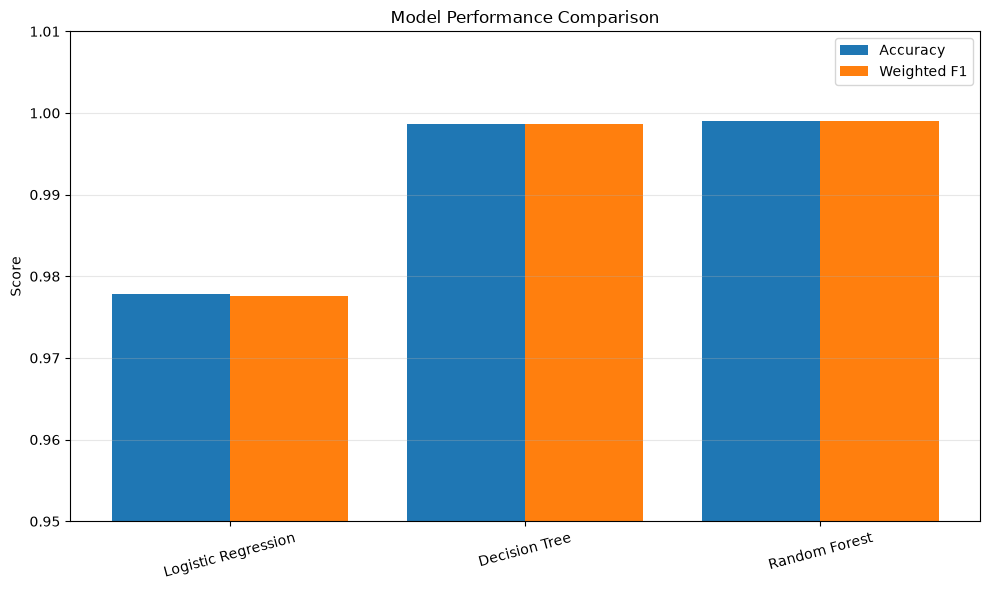

In [43]:
import matplotlib.pyplot as plt

# Model performance comparison

plt.figure(figsize=(10, 6))

x = range(len(model_comparison))

plt.bar(
    [i - 0.2 for i in x],
    model_comparison["Accuracy"],
    width=0.4,
    label="Accuracy"
)

plt.bar(
    [i + 0.2 for i in x],
    model_comparison["F1_Weighted"],
    width=0.4,
    label="Weighted F1"
)

plt.xticks(x, model_comparison["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0.95, 1.01)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

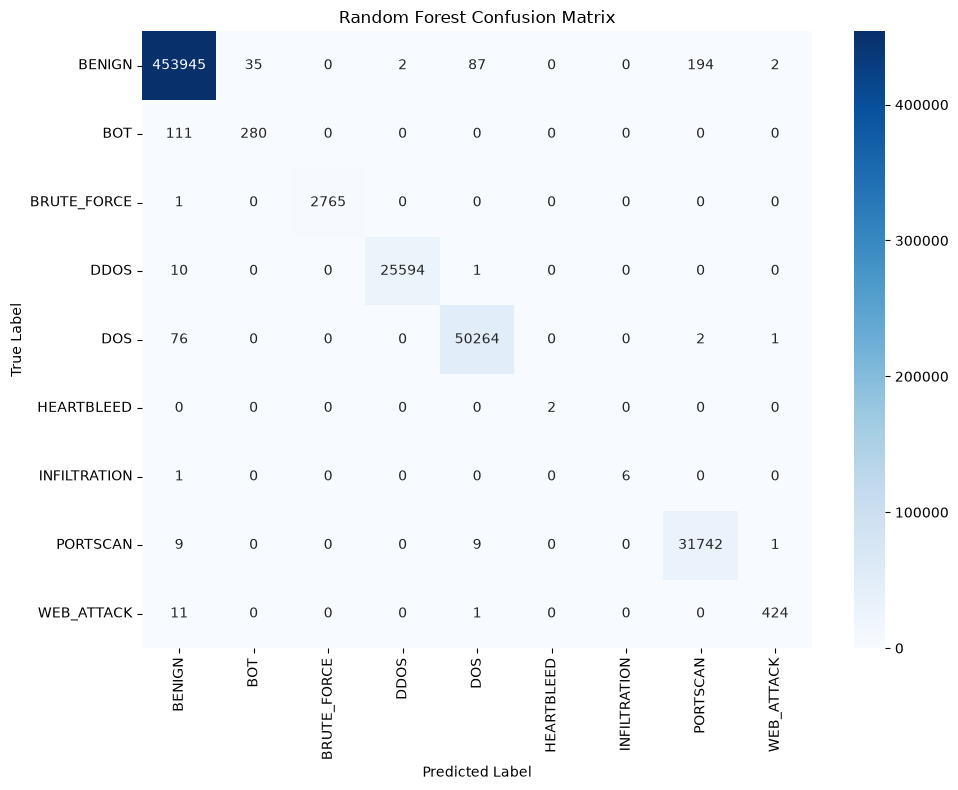

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest confusion matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=random_forest_model.classes_,
    yticklabels=random_forest_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,Bwd Packet Length Std,0.052649
1,Packet Length Variance,0.050338
2,Bwd Packet Length Mean,0.048195
3,Average Packet Size,0.047300
4,Avg Bwd Segment Size,0.044664
5,Destination Port,0.044304
6,Total Length of Fwd Packets,0.038805
7,Subflow Fwd Bytes,0.038118
8,Packet Length Mean,0.037595
9,Subflow Bwd Bytes,0.034038


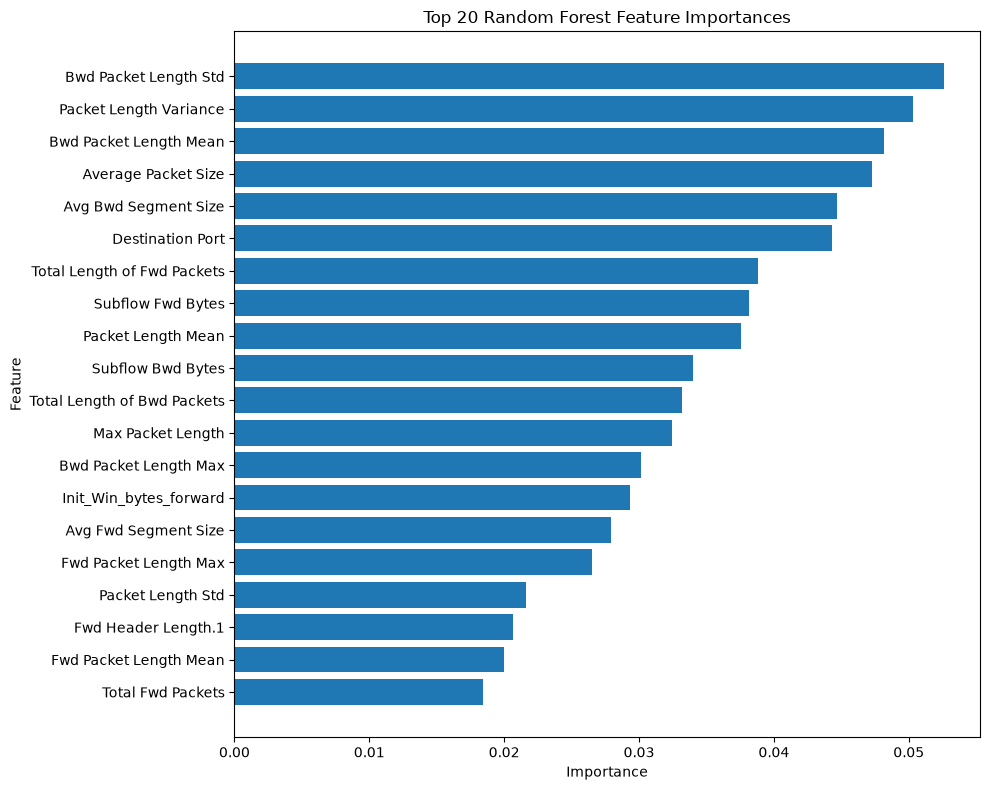

In [46]:
# Random Forest top-20 feature importance

top_features = feature_importance.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()

plt.savefig(
    "../results/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# Save complete Random Forest feature importance

feature_importance.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")
print("Number of features:", len(feature_importance))

Feature importance table saved successfully.
Number of features: 70


In [48]:
feature_importance.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")
print("Number of features:", len(feature_importance))

Feature importance table saved successfully.
Number of features: 70


In [49]:
# Prepare data for SHAP explainability

import shap

# Use a representative sample of the test set
SHAP_SAMPLE_SIZE = 1000

X_shap = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# Create SHAP TreeExplainer for Random Forest
explainer = shap.TreeExplainer(random_forest_model)

print("SHAP TreeExplainer created successfully.")

SHAP sample shape: (1000, 70)
SHAP TreeExplainer created successfully.


In [50]:
# Calculate SHAP values for the sample

X_shap_scaled = scaler.transform(X_shap)

print("Calculating SHAP values...")

shap_values = explainer.shap_values(X_shap_scaled)

print("SHAP values calculated successfully.")
print("SHAP values type:", type(shap_values))

Calculating SHAP values...
SHAP values calculated successfully.
SHAP values type: <class 'numpy.ndarray'>


In [51]:
# Check SHAP value dimensions

print("SHAP values shape:", shap_values.shape)
print("SHAP sample shape:", X_shap_scaled.shape)
print("Number of classes:", len(random_forest_model.classes_))
print("Classes:", random_forest_model.classes_)

SHAP values shape: (1000, 70, 9)
SHAP sample shape: (1000, 70)
Number of classes: 9
Classes: ['BENIGN' 'BOT' 'BRUTE_FORCE' 'DDOS' 'DOS' 'HEARTBLEED' 'INFILTRATION'
 'PORTSCAN' 'WEB_ATTACK']


In [52]:
# Calculate global SHAP feature importance

import numpy as np

# Average absolute SHAP contribution across samples and classes
global_shap_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 2)
)

shap_feature_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": global_shap_importance
})

shap_feature_importance = shap_feature_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Top 20 SHAP features:")
shap_feature_importance.head(20)

Top 20 SHAP features:


,Feature,Mean_Absolute_SHAP
0,Destination Port,0.005857
1,Bwd Packet Length Std,0.005255
2,Packet Length Mean,0.005249
3,Average Packet Size,0.005136
4,Total Length of Bwd Packets,0.004930
5,Bwd Packet Length Mean,0.004404
6,Packet Length Variance,0.003798
7,Max Packet Length,0.003753
8,Avg Bwd Segment Size,0.003594
9,Total Length of Fwd Packets,0.003329


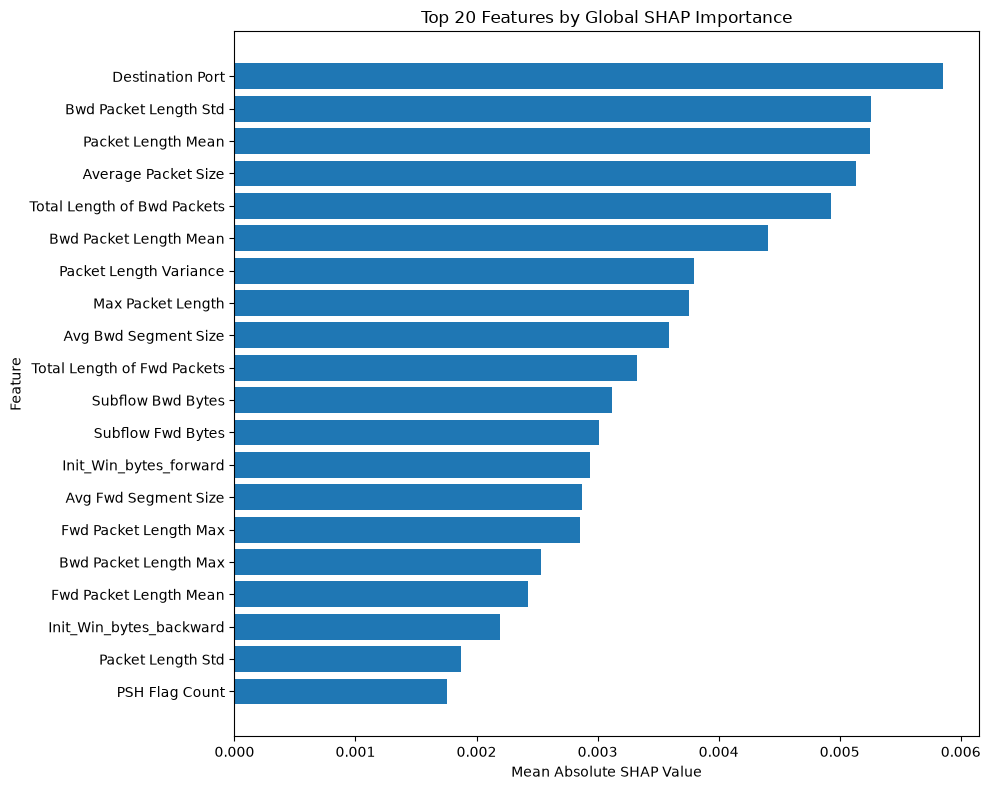

In [53]:
# SHAP global feature importance plot

top_shap_features = shap_feature_importance.head(20).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features by Global SHAP Importance")

plt.tight_layout()

plt.savefig(
    "../results/shap_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
# Save complete SHAP feature importance

shap_feature_importance.to_csv(
    "../results/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance table saved successfully.")
print("Number of features:", len(shap_feature_importance))

SHAP feature importance table saved successfully.
Number of features: 70


In [55]:
# Select one network flow for individual explanation

sample_index = 0

sample_features = X_shap_scaled[sample_index].reshape(1, -1)

sample_prediction = random_forest_model.predict(sample_features)[0]
sample_actual = y_shap.iloc[sample_index] if "y_shap" in globals() else y_test.loc[X_shap.index[sample_index]]

print("Individual SHAP Explanation")
print("---------------------------")
print("Sample index:", sample_index)
print("Actual class:", sample_actual)
print("Predicted class:", sample_prediction)

Individual SHAP Explanation
---------------------------
Sample index: 0
Actual class: BENIGN
Predicted class: BENIGN


In [56]:
# Extract SHAP values for the selected flow

sample_shap_values = shap_values[sample_index, :, :]

print("Individual SHAP values shape:", sample_shap_values.shape)

Individual SHAP values shape: (70, 9)


In [57]:
# Analyze feature contributions for the predicted class

predicted_class_index = list(
    random_forest_model.classes_
).index(sample_prediction)

sample_class_shap = sample_shap_values[:, predicted_class_index]

individual_shap = pd.DataFrame({
    "Feature": X_shap.columns,
    "SHAP_Value": sample_class_shap
})

individual_shap["Absolute_SHAP"] = individual_shap["SHAP_Value"].abs()

individual_shap = individual_shap.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Predicted class:", sample_prediction)
print("Top 10 features influencing this prediction:")
individual_shap.head(10)

Predicted class: BENIGN
Top 10 features influencing this prediction:


,Feature,SHAP_Value,Absolute_SHAP
0,Fwd IAT Min,0.030631,0.030631
1,Packet Length Mean,-0.022852,0.022852
2,Fwd Packets/s,0.021228,0.021228
3,Destination Port,-0.020350,0.020350
4,Flow Duration,0.017934,0.017934
5,Bwd Packets/s,0.017229,0.017229
6,Flow IAT Max,0.014301,0.014301
7,Init_Win_bytes_forward,0.014149,0.014149
8,Flow IAT Mean,0.013549,0.013549
9,Flow Packets/s,0.011164,0.011164


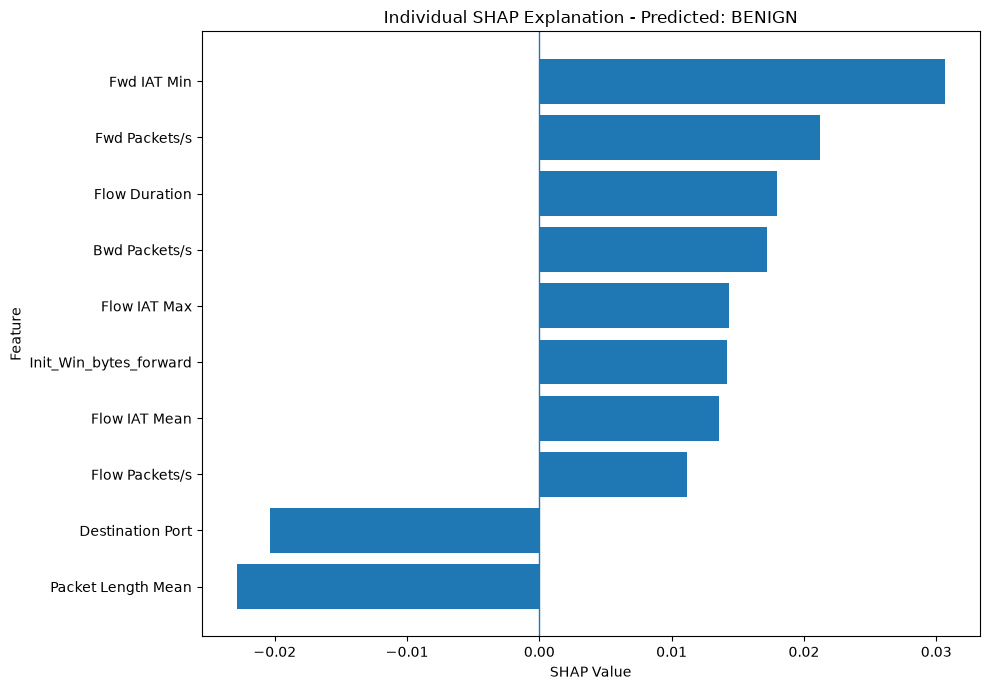

In [58]:
# Individual SHAP explanation graph

top_individual = individual_shap.head(10).sort_values(
    by="SHAP_Value",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_individual["Feature"],
    top_individual["SHAP_Value"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"Individual SHAP Explanation - Predicted: {sample_prediction}"
)

plt.tight_layout()

plt.savefig(
    "../results/individual_shap_explanation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
# Save individual SHAP explanation

individual_shap.to_csv(
    "../results/individual_shap_explanation.csv",
    index=False
)

print("Individual SHAP explanation saved successfully.")
print("Number of features:", len(individual_shap))

Individual SHAP explanation saved successfully.
Number of features: 70


In [60]:
# Compare Random Forest importance with SHAP importance

rf_top20 = set(
    feature_importance.head(20)["Feature"]
)

shap_top20 = set(
    shap_feature_importance.head(20)["Feature"]
)

common_features = rf_top20.intersection(shap_top20)

print("Random Forest top 20 features:", len(rf_top20))
print("SHAP top 20 features:", len(shap_top20))
print("Common features:", len(common_features))

print("\nCommon important features:")
for feature in sorted(common_features):
    print(feature)

Random Forest top 20 features: 20
SHAP top 20 features: 20
Common features: 18

Common important features:
Average Packet Size
Avg Bwd Segment Size
Avg Fwd Segment Size
Bwd Packet Length Max
Bwd Packet Length Mean
Bwd Packet Length Std
Destination Port
Fwd Packet Length Max
Fwd Packet Length Mean
Init_Win_bytes_forward
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
Subflow Bwd Bytes
Subflow Fwd Bytes
Total Length of Bwd Packets
Total Length of Fwd Packets


In [61]:
# Save Random Forest vs SHAP feature importance comparison

rf_importance_compare = feature_importance[
    ["Feature", "Importance"]
].copy()

rf_importance_compare = rf_importance_compare.rename(
    columns={"Importance": "RF_Importance"}
)

shap_importance_compare = shap_feature_importance[
    ["Feature", "Mean_Absolute_SHAP"]
].copy()

feature_importance_comparison = pd.merge(
    rf_importance_compare,
    shap_importance_compare,
    on="Feature",
    how="outer"
)

feature_importance_comparison["RF_Rank"] = (
    feature_importance_comparison["RF_Importance"]
    .rank(ascending=False, method="min")
)

feature_importance_comparison["SHAP_Rank"] = (
    feature_importance_comparison["Mean_Absolute_SHAP"]
    .rank(ascending=False, method="min")
)

feature_importance_comparison = feature_importance_comparison.sort_values(
    by="SHAP_Rank"
)

feature_importance_comparison.to_csv(
    "../results/feature_importance_comparison.csv",
    index=False
)

print("Feature importance comparison saved successfully.")
print("Number of features:", len(feature_importance_comparison))
print("\nTop 20 features:")
print(feature_importance_comparison.head(20).to_string(index=False))

Feature importance comparison saved successfully.
Number of features: 70

Top 20 features:
                    Feature  RF_Importance  Mean_Absolute_SHAP  RF_Rank  SHAP_Rank
           Destination Port       0.044304            0.005857      6.0        1.0
      Bwd Packet Length Std       0.052649            0.005255      1.0        2.0
         Packet Length Mean       0.037595            0.005249      9.0        3.0
        Average Packet Size       0.047300            0.005136      4.0        4.0
Total Length of Bwd Packets       0.033169            0.004930     11.0        5.0
     Bwd Packet Length Mean       0.048195            0.004404      3.0        6.0
     Packet Length Variance       0.050338            0.003798      2.0        7.0
          Max Packet Length       0.032408            0.003753     12.0        8.0
       Avg Bwd Segment Size       0.044664            0.003594      5.0        9.0
Total Length of Fwd Packets       0.038805            0.003329      7.0       1

In [62]:
import joblib
import os

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save trained Random Forest model
joblib.dump(
    random_forest_model,
    "../models/random_forest_ids.pkl"
)

# Save StandardScaler
joblib.dump(
    scaler,
    "../models/standard_scaler.pkl"
)

# Save feature names
joblib.dump(
    list(X_train.columns),
    "../models/feature_names.pkl"
)

# Save class names
joblib.dump(
    list(random_forest_model.classes_),
    "../models/class_names.pkl"
)

print("Model files saved successfully.")
print("Random Forest:", os.path.exists("../models/random_forest_ids.pkl"))
print("Scaler:", os.path.exists("../models/standard_scaler.pkl"))
print("Feature names:", os.path.exists("../models/feature_names.pkl"))
print("Class names:", os.path.exists("../models/class_names.pkl"))

Model files saved successfully.
Random Forest: True
Scaler: True
Feature names: True
Class names: True


In [ ]:
import joblib

# Load saved model artifacts
loaded_model = joblib.load("../models/random_forest_ids.pkl")
loaded_scaler = joblib.load("../models/standard_scaler.pkl")
loaded_features = joblib.load("../models/feature_names.pkl")
loaded_classes = joblib.load("../models/class_names.pkl")

print("Saved model loaded successfully.")
print("Model type:", type(loaded_model).__name__)
print("Number of features:", len(loaded_features))
print("Number of classes:", len(loaded_classes))
print("Classes:", loaded_classes)

# Verify the loaded model can make a prediction
test_sample = X_test.iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)

prediction = loaded_model.predict(test_sample_scaled)[0]

print("\nTest prediction:", prediction)
print("Actual class:", y_test.iloc[0])

SyntaxError: invalid syntax (3154151984.py, line 8)